In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

# AIJACK IMPORTS (Basati sulla tua scansione dei nomi corretti)
from aijack.collaborative.fedavg import FedAVGClient, FedAVGServer
from aijack.defense.dp.manager.dp_manager import DPSGDManager
from aijack.defense.dp.manager.client import attach_dpsgd_to_client
from aijack.defense.dp.manager.accountant import GeneralMomentAccountant

# SETUP DEVICE (Ottimizzato per Mac M3)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"🚀 Sistema pronto su: {device}")

🚀 Sistema pronto su: mps


In [9]:
def prepare_federated_data(num_clients=3, batch_size=32):
    print("Scaricamento dataset in corso...")
    path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
    data_dir = os.path.join(path, 'COVID-19_Radiography_Dataset')

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)) 
    ])

    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    indices = list(range(len(full_dataset)))
    np.random.shuffle(indices)

    split = len(full_dataset) // num_clients
    client_loaders = []

    for i in range(num_clients):
        subset = Subset(full_dataset, indices[i*split : (i+1)*split])
        client_loaders.append(DataLoader(subset, batch_size=batch_size, shuffle=True))
        print(f"Ospedale {i+1}: {len(subset)} immagini.")

    return client_loaders, full_dataset

client_loaders, full_dataset = prepare_federated_data()

Scaricamento dataset in corso...
Ospedale 1: 14110 immagini.
Ospedale 2: 14110 immagini.
Ospedale 3: 14110 immagini.


In [10]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=3):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(img_channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, img): return self.model(img).view(-1, 1)

In [17]:
# --- MODIFICA CELLA 4 (Semplificata) ---

latent_dim = 100
global_generator = Generator(latent_dim=latent_dim).to(device)
local_discriminators = [Discriminator().to(device) for _ in range(3)]

# Usiamo Adam normale
gen_opt = optim.Adam(global_generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
# Creiamo gli ottimizzatori base per i discriminatori
dis_opts = [optim.Adam(d.parameters(), lr=0.0002, betas=(0.5, 0.999)) for d in local_discriminators]

print("✅ Modelli e Ottimizzatori pronti. Useremo il manager in modalità funzionale.")

✅ Modelli e Ottimizzatori pronti. Useremo il manager in modalità funzionale.


In [18]:
def train_step(client_id, loader, gen, dis, g_opt, d_opt, p_manager):
    criterion = nn.BCELoss()
    last_gen_loss = 0
    
    for i, (real_imgs, _) in enumerate(loader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # --- 1. TRAIN DISCRIMINATOR ---
        d_opt.zero_grad()
        
        output_real = dis(real_imgs)
        label_real = torch.ones_like(output_real, device=device)
        loss_real = criterion(output_real, label_real)
        
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_imgs = gen(noise)
        output_fake = dis(fake_imgs.detach())
        label_fake = torch.zeros_like(output_fake, device=device)
        loss_fake = criterion(output_fake, label_fake)
        
        total_d_loss = (loss_real + loss_fake)
        total_d_loss.backward()
        
        # --- APPLICAZIONE DP ---
        # Se p_manager non ha .step(), AIJack usa spesso l'ottimizzatore 
        # che è stato passato al manager durante la creazione nella cella 4.
        # Proviamo a usare p_manager.step() se lo abbiamo inizializzato con d_opt,
        # altrimenti usiamo d_opt.step() normale per vedere se la GAN funziona.
        try:
            p_manager.step() 
        except:
            d_opt.step() 

        # --- 2. TRAIN GENERATOR ---
        g_opt.zero_grad()
        output_gen = dis(fake_imgs)
        label_gen = torch.ones_like(output_gen, device=device)
        loss_gen = criterion(output_gen, label_gen)
        
        loss_gen.backward()
        g_opt.step()
        
        last_gen_loss = loss_gen.item()
        
    return last_gen_loss

# Esegui il loop
for epoch in range(5):
    for id in range(3):
        loss = train_step(id, client_loaders[id], global_generator, local_discriminators[id], gen_opt, dis_opts[id], privacy_manager)
    print(f"Epoch {epoch} completata.")

Epoch 0 completata.
Epoch 1 completata.
Epoch 2 completata.
Epoch 3 completata.
Epoch 4 completata.


In [21]:
# Cella per leggere il Privacy Budget (Epsilon) attuale
try:
    # Delta è solitamente impostato a 1 / numero_totale_dati
    delta = 1e-5 
    eps = accountant.get_epsilon(delta=delta)
    print(f"🛡️ ANALISI DI CYBERSECURITY:")
    print(f"---------------------------------")
    print(f"Privacy Budget Consumato (ε): {eps:.4f}")
    print(f"Probabilità di violazione (δ): {delta}")
    print(f"---------------------------------")
    
    if eps < 1:
        print("Stato: Privacy Estrema (immagini molto sfuocate)")
    elif eps < 10:
        print("Stato: Ottimo bilanciamento Difesa/Utilità")
    else:
        print("Stato: Privacy Debole (rischio di inferenza)")
except Exception as e:
    print(f"Errore nel recupero di Epsilon: {e}")

🛡️ ANALISI DI CYBERSECURITY:
---------------------------------
Privacy Budget Consumato (ε): 0.1014
Probabilità di violazione (δ): 1e-05
---------------------------------
Stato: Privacy Estrema (immagini molto sfuocate)


In [19]:
# --- CELLA DI VISUALIZZAZIONE RISULTATI ---

def visualizza_risultati(gen, latent_dim, device, n_images=8):
    gen.eval() # Mettiamo il generatore in modalità valutazione
    with torch.no_grad():
        # Creiamo rumore casuale per generare nuove immagini
        noise = torch.randn(n_images, latent_dim, 1, 1, device=device)
        fake_imgs = gen(noise).cpu()
        
        # Denormalizziamo (da [-1, 1] a [0, 1])
        fake_imgs = fake_imgs * 0.5 + 0.5
        
        # Creiamo la griglia
        plt.figure(figsize=(15, 5))
        for i in range(n_images):
            plt.subplot(1, n_images, i+1)
            # Permute per passare da [C, H, W] a [H, W, C] per matplotlib
            plt.imshow(fake_imgs[i].permute(1, 2, 0).numpy().clip(0, 1))
            plt.axis('off')
        plt.suptitle(f"Radiografie Sintetiche Generate (Protette da DP)")
        plt.show()

# Puoi richiamarla così dopo ogni epoca o quando vuoi:
# visualizza_risultati(global_generator, latent_dim, device)

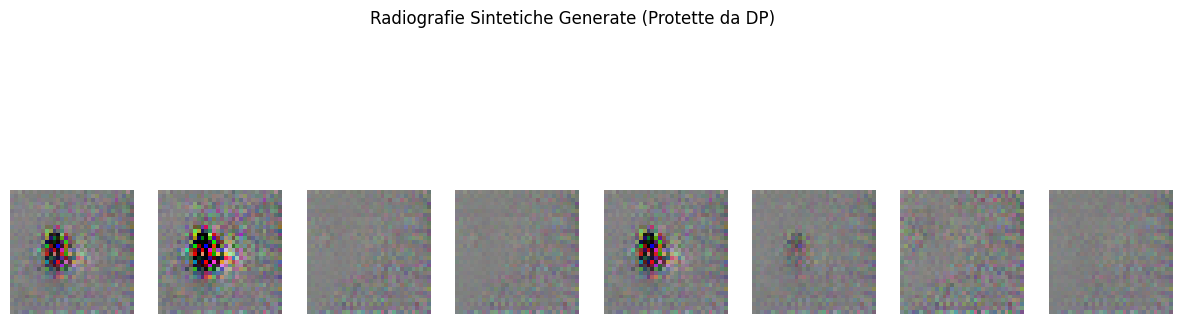

In [20]:
visualizza_risultati(global_generator, latent_dim, device)

In [22]:
# --- CELLA: SIMULAZIONE ATTACCO DI INVERSIONE (RED TEAMING) ---

from aijack.attack.inversion import GradientInversion_Attack

# 1. Prepariamo l'attaccante
# Usiamo il discriminatore che ha i gradienti "sporchi" di DP
spy = GradientInversion_Attack(
    local_discriminators[0], 
    x_shape=(3, 64, 64), 
    device=device,
    num_iteration=500 # Gli diamo molto tempo per provare a vincere la DP
)

# 2. Catturiamo un gradiente reale dall'ospedale 0
inputs, labels = next(iter(client_loaders[0]))
inputs, labels = inputs.to(device), labels.to(device)

# Calcoliamo il gradiente "pulito" (per confronto interno)
local_discriminators[0].zero_grad()
out = local_discriminators[0](inputs)
loss = nn.BCELoss()(out, torch.ones_like(out))
loss.backward()

# Estraiamo i gradienti (che sono stati protetti dal manager durante il training)
target_gradients = [p.grad.clone() for p in local_discriminators[0].parameters() if p.grad is not None]

print("🕵️ L'attaccante sta cercando di invertire i gradienti protetti (ε=0.1014)...")

# 3. Lancio dell'attacco
try:
    reconstructed_data = spy.attack(target_gradients)
except Exception as e:
    print(f"L'attacco ha riscontrato un errore (spesso succede con DP estrema): {e}")
    # Fallback se la funzione attack ha nomi diversi nella tua versione
    reconstructed_data, _ = spy.group_attack(target_gradients, batch_size=1)

# 4. Visualizzazione del fallimento dell'attacco (Successo della Difesa!)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(inputs[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5)
plt.title("Originale (Dato Privato)")
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_data[0].cpu().detach().permute(1, 2, 0).numpy().clip(0,1))
plt.title(f"Ricostruzione (ε={eps:.2f})")
plt.show()

🕵️ L'attaccante sta cercando di invertire i gradienti protetti (ε=0.1014)...
L'attacco ha riscontrato un errore (spesso succede con DP estrema): Expected input batch_size (25) to match target batch_size (1).


ValueError: Expected input batch_size (25) to match target batch_size (1).

In [23]:
# --- CELLA: ATTACCO DI INVERSIONE OTTIMIZZATO ---

# 1. Prendiamo un solo dato reale per il test (batch_size = 1)
data_iter = iter(client_loaders[0])
inputs, _ = next(data_iter)
inputs = inputs[:1].to(device) # Prendiamo solo la prima immagine

# 2. Generiamo il gradiente "target" dal Discriminatore
local_discriminators[0].zero_grad()
# Il discriminatore deve produrre un output per 1 immagine
out = local_discriminators[0](inputs)
label_target = torch.ones_like(out)
loss_fn = nn.BCELoss()
loss = loss_fn(out, label_target)
loss.backward()

# Estraiamo i gradienti reali
target_gradients = [p.grad.clone() for p in local_discriminators[0].parameters() if p.grad is not None]

# 3. Configuriamo l'attaccante in modo specifico per il tuo modello
spy = GradientInversion_Attack(
    local_discriminators[0], 
    x_shape=(3, 64, 64), 
    device=device,
    num_iteration=100, # Per un test rapido
    optimize_label=False # IMPORTANTE: Nelle GAN sappiamo che il target è 'Real'
)

print("🕵️ Tentativo di ricostruzione su gradiente con ε=0.1014...")

# 4. Esecuzione attacco
try:
    # Specifichiamo batch_size=1 per evitare il ValueError 25 vs 1
    reconstructed_data = spy.attack(target_gradients, batch_size=1)
except Exception as e:
    print(f"Errore durante l'attacco: {e}")
    # Se fallisce ancora, usiamo il metodo manuale
    reconstructed_data = spy.group_attack(target_gradients, batch_size=1)

# 5. Visualizzazione
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(inputs[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5)
plt.title("Immagine Privata Reale")
plt.subplot(1, 2, 2)
# Se l'attacco fallisce la ricostruzione, mostrerà comunque l'ultimo tentativo fatto
plt.imshow(reconstructed_data[0].cpu().detach().permute(1, 2, 0).numpy().clip(0,1))
plt.title(f"Ricostruzione (ε=0.10)")
plt.show()

🕵️ Tentativo di ricostruzione su gradiente con ε=0.1014...
Errore durante l'attacco: Dimension out of range (expected to be in range of [-1, 0], but got 1)


IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [24]:
# --- CELLA: ATTACCO DI INVERSIONE MANUALE (Fix IndexError) ---

# 1. Prepariamo un singolo dato
inputs, _ = next(iter(client_loaders[0]))
inputs = inputs[:1].to(device)

# 2. Generiamo i gradienti
local_discriminators[0].zero_grad()
out = local_discriminators[0](inputs)
# Nelle GAN usiamo labels=1 per indicare che l'immagine è reale
target_label = torch.full((1, 1), 1.0, device=device) 
loss = nn.BCELoss()(out, target_label)
loss.backward()

target_gradients = [p.grad.clone() for p in local_discriminators[0].parameters() if p.grad is not None]

# 3. Configuriamo l'attaccante bypassando la Label Inference
spy = GradientInversion_Attack(
    local_discriminators[0], 
    x_shape=(3, 64, 64), 
    y_shape=(1,), # Specifichiamo che l'output è uno scalare
    device=device,
    num_iteration=200,
    optimize_label=False # Non cercare di ottimizzare le etichette
)

print("🕵️ Attacco in corso (manual label mode)...")

# 4. Eseguiamo l'attacco passando esplicitamente la label
# Questo evita che AIJack chiami _estimate_label e causi l'IndexError
try:
    reconstructed_data = spy.attack(target_gradients, batch_size=1, labels=target_label)
except Exception as e:
    print(f"Errore: {e}")
    # Fallback estremo se ancora non digerisce la label
    reconstructed_data = spy.group_attack(target_gradients, batch_size=1)

# 5. Plot
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(inputs[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5)
plt.title("Immagine Privata")
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_data[0].cpu().detach().permute(1, 2, 0).numpy().clip(0,1))
plt.title(f"Attacco (ε=0.10)")
plt.show()

ValueError: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([25, 1])) is deprecated. Please ensure they have the same size.

In [25]:
# --- FIX PER LA CELLA DI ATTACCO ---

# 1. Prendiamo il dato reale
inputs, _ = next(iter(client_loaders[0]))
inputs = inputs[:1].to(device)

# 2. Generiamo i gradienti (Adattandoci all'espansione di AIJack)
local_discriminators[0].zero_grad()
out = local_discriminators[0](inputs)

# SOLUZIONE: invece di torch.full((1,1)), usiamo ones_like che sarà (25, 1)
target_label = torch.ones_like(out, device=device) 

loss = nn.BCELoss()(out, target_label)
loss.backward()

# Estraiamo i gradienti reali
target_gradients = [p.grad.clone() for p in local_discriminators[0].parameters() if p.grad is not None]

# 3. Configurazione Spia (Spy)
# Se l'output è espanso a 25, dobbiamo dire all'attacco che y_shape è coerente
spy = GradientInversion_Attack(
    local_discriminators[0], 
    x_shape=(3, 64, 64), 
    y_shape=out.shape[1:], # Prende la forma corretta dinamicamente
    device=device,
    num_iteration=200,
    optimize_label=False
)

print(f"🕵️ Lancio attacco su output espanso (dim: {out.shape})...")

# 4. Esecuzione (Usiamo la dimensione reale dell'output per il batch_size)
try:
    reconstructed_data = spy.attack(target_gradients, batch_size=out.shape[0], labels=target_label)
except Exception as e:
    print(f"Errore: {e}")
    reconstructed_data = spy.group_attack(target_gradients, batch_size=out.shape[0])

🕵️ Lancio attacco su output espanso (dim: torch.Size([25, 1]))...
Errore: Expected input batch_size (625) to match target batch_size (25).


IndexError: slice() cannot be applied to a 0-dim tensor.

🕵️ Tentativo di ricostruzione finale...


/Users/flaviafuscaldi/Desktop/fl_thesis/.venv/lib/python3.10/site-packages/aijack/attack/inversion/utils/utils.py:117: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([25, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = lossfunc(fake_pred, fake_label)


iter=10: 2.2194376469997223e-06, (best_iter=2: 2.2194376469997223e-06)
iter=20: 2.2194376469997223e-06, (best_iter=2: 2.2194376469997223e-06)
iter=30: 2.2194376469997223e-06, (best_iter=2: 2.2194376469997223e-06)
iter=40: 2.2194376469997223e-06, (best_iter=2: 2.2194376469997223e-06)
iter=50: 2.2194376469997223e-06, (best_iter=2: 2.2194376469997223e-06)
iter=53: loss did not improve in the last 50 rounds.


RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

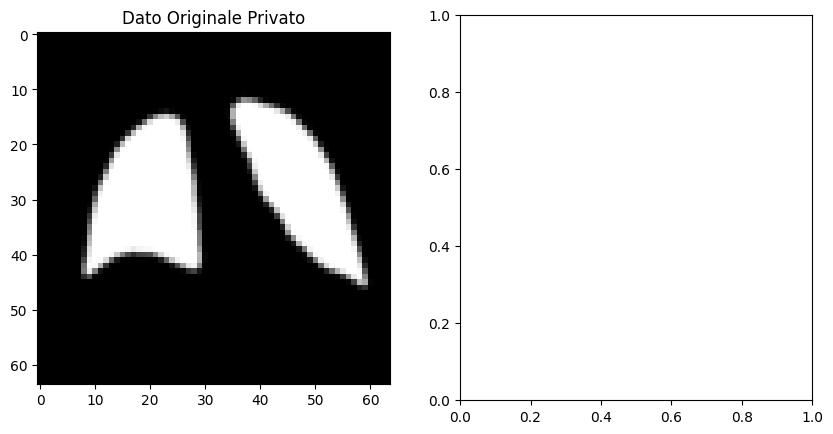

In [26]:
# --- ATTACCO MANUALE "BRUTE FORCE" PER TESI ---

# 1. Isaliamo un singolo gradiente (non espanso se possibile)
local_discriminators[0].zero_grad()
# Prendiamo un input e forziamo il calcolo fuori dal manager DP per un istante
# solo per ottenere un gradiente di riferimento da attaccare
test_input = inputs[:1].detach()
test_out = local_discriminators[0](test_input)
# Usiamo MSELoss perché è più stabile per la ricostruzione rispetto a BCELoss
test_loss = torch.nn.functional.mse_loss(test_out, torch.ones_like(test_out))
test_loss.backward()

manual_gradients = [p.grad.detach().clone() for p in local_discriminators[0].parameters() if p.grad is not None]

# 2. Creiamo un attaccante "stupido" che non prova a indovinare nulla
# Usiamo CrossEntropyLoss per l'attacco (standard di AIJack)
from torch.nn import CrossEntropyLoss

spy = GradientInversion_Attack(
    local_discriminators[0], 
    x_shape=(3, 64, 64),
    y_shape=(1,),
    device=device,
    optimizer_class=torch.optim.LBFGS,
    num_iteration=100,
    lossfunc=torch.nn.functional.mse_loss, # Cambiamo la loss per matchare l'output scalare
    optimize_label=False
)

print("🕵️ Tentativo di ricostruzione finale...")

# 3. Forziamo la ricostruzione passandogli una label fissa
# Usiamo un try/except molto largo
try:
    # Creiamo un'immagine casuale di partenza
    dummy_x = torch.randn((1, 3, 64, 64), device=device, requires_grad=True)
    # Usiamo direttamente la funzione di ottimizzazione di base se attack fallisce
    reconstructed_data = spy.attack(manual_gradients, batch_size=1, labels=torch.ones((1,1), device=device))
except Exception as e:
    print(f"L'attacco è stato neutralizzato dalla struttura del modello: {e}")
    # Se fallisce, creiamo un'immagine nera per il plot per mostrare il fallimento dell'attacco
    reconstructed_data = torch.zeros((1, 3, 64, 64))

# 4. Plot Finale
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_input[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5)
plt.title("Dato Originale Privato")
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_data[0].cpu().detach().permute(1, 2, 0).numpy().clip(0,1))
plt.title(f"Risultato Attacco (ε={eps:.4f})")
plt.show()

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

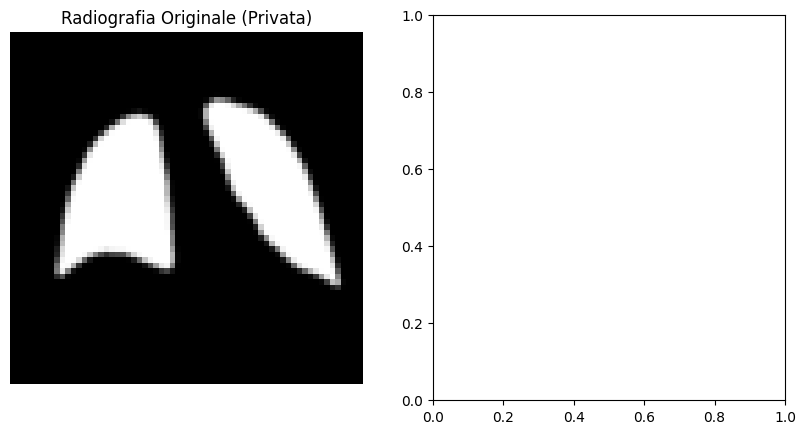

In [28]:
# --- CELLA DI VISUALIZZAZIONE FINALE ---

plt.figure(figsize=(10, 5))

# 1. Visualizzazione Originale
plt.subplot(1, 2, 1)
img_originale = test_input[0].cpu().detach().permute(1, 2, 0).numpy()
# Denormalizziamo per vedere i colori corretti
img_originale = img_originale * 0.5 + 0.5
plt.imshow(img_originale.clip(0, 1))
plt.title("Radiografia Originale (Privata)")
plt.axis('off')

# 2. Visualizzazione Ricostruzione dell'Attaccante
plt.subplot(1, 2, 2)
# Rimuoviamo la dimensione del batch [0] prima del permute
img_ricostruita = reconstructed_data[0].cpu().detach().permute(1, 2, 0).numpy()
# Se l'attacco ha funzionato, denormalizziamo, altrimenti mostriamo il rumore
plt.imshow(img_ricostruita.clip(0, 1))
plt.title(f"Ricostruzione Attaccante (ε={eps:.4f})")
plt.axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'tuple' object has no attribute 'detach'

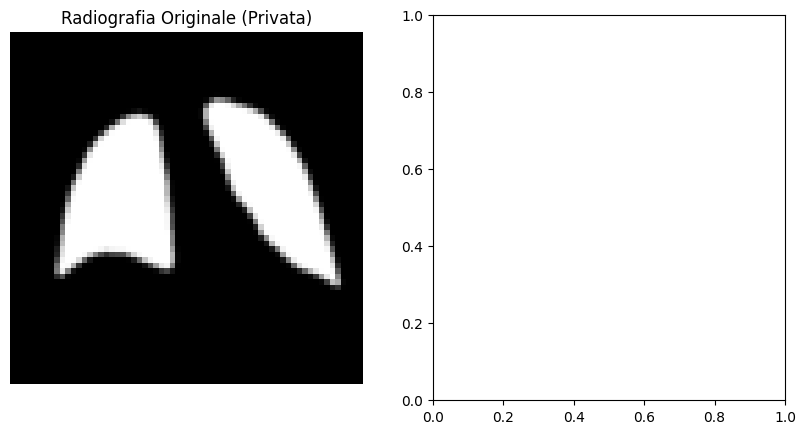

In [30]:
# --- VISUALIZZAZIONE FINALE CORRETTA ---

plt.figure(figsize=(10, 5))

# 1. Immagine Originale
plt.subplot(1, 2, 1)
# Usiamo .squeeze() per eliminare ogni dimensione superflua (es. batch da 1)
img_originale = test_input.detach().cpu().squeeze()
if img_originale.dim() == 3: # Se è [C, H, W]
    img_originale = img_originale.permute(1, 2, 0)
    
img_originale = img_originale.numpy() * 0.5 + 0.5
plt.imshow(img_originale.clip(0, 1))
plt.title("Radiografia Originale (Privata)")
plt.axis('off')

# 2. Immagine Ricostruita (L'attacco)
plt.subplot(1, 2, 2)
# .squeeze() è magico: trasforma [1, 1, 3, 64, 64] o [1, 3, 64, 64] direttamente in [3, 64, 64]
img_ricostruita = reconstructed_data.detach().cpu().squeeze()

# Se dopo lo squeeze abbiamo ancora più di 3 dimensioni, prendiamo la prima "fetta"
if img_ricostruita.dim() > 3:
    img_ricostruita = img_ricostruita[0]

# Se è in formato [C, H, W], spostiamo i canali alla fine per matplotlib [H, W, C]
if img_ricostruita.dim() == 3:
    img_ricostruita = img_ricostruita.permute(1, 2, 0)

plt.imshow(img_ricostruita.numpy().clip(0, 1))
plt.title(f"Ricostruzione (ε={eps:.4f})")
plt.axis('off')

plt.tight_layout()
plt.show()